In [1]:
# --- 1. Import libraries ---
import os
import sys
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Manually define the correct project root path based on your previous output
CORRECT_PROJECT_ROOT = "/home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one"

# Set CWD
try:
    os.chdir(CORRECT_PROJECT_ROOT)
    print(f"✅ CWD successfully set to: {os.getcwd()}")

    # Add to sys.path for module imports (src.helpers)
    if CORRECT_PROJECT_ROOT not in sys.path:
        sys.path.append(CORRECT_PROJECT_ROOT)
        print("✅ Added project root to sys.path.")

except FileNotFoundError:
    print("❌ CRITICAL ERROR: The manually defined project path does not exist.")
    sys.exit(1)

✅ CWD successfully set to: /home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one
✅ Added project root to sys.path.


In [2]:
import pandas as pd

df = pd.read_csv("data/processed/tips_synthetic.csv")

# Encode gender/smoker safely
df_work = df.copy()

if "gender" in df_work.columns and "gender_Male" not in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["gender"], prefix="gender", drop_first=True)

if "is_smoker" in df_work.columns and "is_smoker_Yes" not in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["is_smoker"], prefix="is_smoker", drop_first=True)

features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
X = df_work[features]
y = df_work["tip_usd"]


In [3]:
df_work.head()

,bill_total_usd,party_size,tip_usd,tip_pct,gender_Male,is_smoker_Yes
0,43.71,1,3.65,0.084,False,True
1,95.56,4,9.88,0.103,True,False
2,75.88,2,7.78,0.103,False,False
3,63.88,4,12.78,0.200,True,False
4,24.04,2,4.36,0.181,False,False


In [7]:
df_work.info

<bound method DataFrame.info of      bill_total_usd  party_size  tip_usd  tip_pct  gender_Male  is_smoker_Yes
0             43.71           1     3.65    0.084        False           True
1             95.56           4     9.88    0.103         True          False
2             75.88           2     7.78    0.103        False          False
3             63.88           4    12.78    0.200         True          False
4             24.04           2     4.36    0.181        False          False
..              ...         ...      ...      ...          ...            ...
395           93.77           4    12.20    0.130         True          False
396           87.26           5    10.17    0.117        False          False
397           48.61           3     6.26    0.129         True           True
398           77.58           3     6.49    0.084         True          False
399           77.91           5     8.15    0.105         True          False

[400 rows x 6 columns]>

### Session 7 Summary — Regularization, Overfitting, and Model Stability

In this session we learned how to diagnose and reduce overfitting in linear models. 
We introduced **Ridge**, **Lasso**, and **ElasticNet** regularization and showed how 
they shrink coefficient magnitudes to improve generalization. We evaluated models using 
**train/test splits**, **cross-validation**, and **RMSE/R² metrics**. We visualized 
**coefficient paths** across different levels of penalty strength to understand model 
stability. We also demonstrated the **bias–variance tradeoff**, showing why models that 
are too simple underfit and models that are too flexible overfit. This session gives us 
a complete toolkit for training reliable linear models that perform well on unseen data.


In [8]:
df_work.info

<bound method DataFrame.info of      bill_total_usd  party_size  tip_usd  tip_pct  gender_Male  is_smoker_Yes
0             43.71           1     3.65    0.084        False           True
1             95.56           4     9.88    0.103         True          False
2             75.88           2     7.78    0.103        False          False
3             63.88           4    12.78    0.200         True          False
4             24.04           2     4.36    0.181        False          False
..              ...         ...      ...      ...          ...            ...
395           93.77           4    12.20    0.130         True          False
396           87.26           5    10.17    0.117        False          False
397           48.61           3     6.26    0.129         True           True
398           77.58           3     6.49    0.084         True          False
399           77.91           5     8.15    0.105         True          False

[400 rows x 6 columns]>

In [10]:
df_work.describe

<bound method NDFrame.describe of      bill_total_usd  party_size  tip_usd  tip_pct  gender_Male  is_smoker_Yes
0             43.71           1     3.65    0.084        False           True
1             95.56           4     9.88    0.103         True          False
2             75.88           2     7.78    0.103        False          False
3             63.88           4    12.78    0.200         True          False
4             24.04           2     4.36    0.181        False          False
..              ...         ...      ...      ...          ...            ...
395           93.77           4    12.20    0.130         True          False
396           87.26           5    10.17    0.117        False          False
397           48.61           3     6.26    0.129         True           True
398           77.58           3     6.49    0.084         True          False
399           77.91           5     8.15    0.105         True          False

[400 rows x 6 columns]>

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = []

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred_train = model.predict(X_train_s)
    y_pred_test  = model.predict(X_test_s)

    results.append({
        "Model": name,
        "Train_R2": r2_score(y_train, y_pred_train),
        "Test_R2": r2_score(y_test, y_pred_test),
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
    })

results_df = pd.DataFrame(results)
results_df


,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE
0,Linear,0.537025,0.365320,2.359253,2.491390
1,Ridge,0.537020,0.365836,2.359266,2.490375
2,Lasso,0.534496,0.366234,2.365688,2.489594
3,ElasticNet,0.534159,0.370737,2.366545,2.480734


<Figure size 1000x600 with 0 Axes>

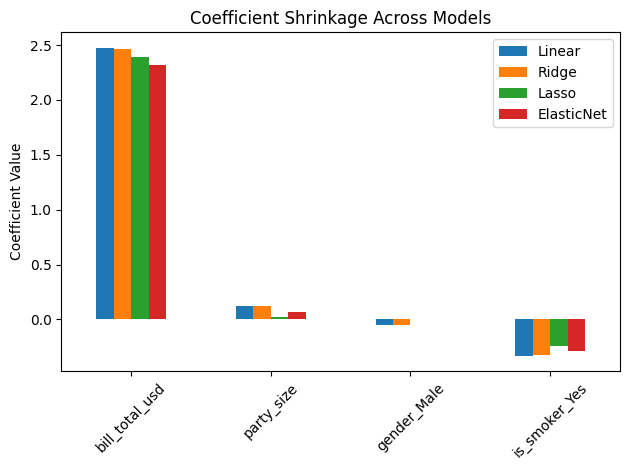

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

coef_df = pd.DataFrame(index=features)

for name, model in models.items():
    coef_df[name] = model.fit(X_train_s, y_train).coef_

plt.figure(figsize=(10,6))
coef_df.plot(kind="bar")
plt.title("Coefficient Shrinkage Across Models")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


• Linear model → coefficients freely bounce around  
• Ridge → pulls them toward zero (but not all the way)  
• Lasso → can delete coefficients (turn them *exactly* zero)  
• ElasticNet → mix of both behaviors  


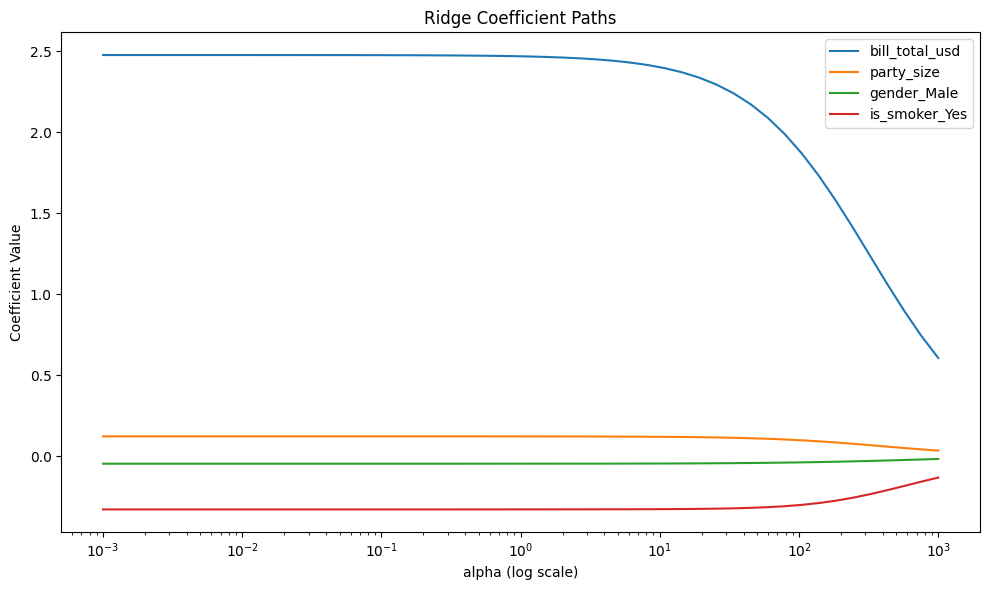

In [15]:
alphas = np.logspace(-3, 3, 50)
coef_paths = []

for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_train_s, y_train)
    coef_paths.append(r.coef_)

coef_paths = np.array(coef_paths)

plt.figure(figsize=(10,6))
for i, feat in enumerate(features):
    plt.plot(alphas, coef_paths[:, i], label=feat)

plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Coefficient Value")
plt.title("Ridge Coefficient Paths")
plt.legend()
plt.tight_layout()
plt.show()


• When alpha is small → model behaves like linear regression  
• As alpha increases → coefficients shrink toward zero  
• Ridge never deletes a feature, it only shrinks  


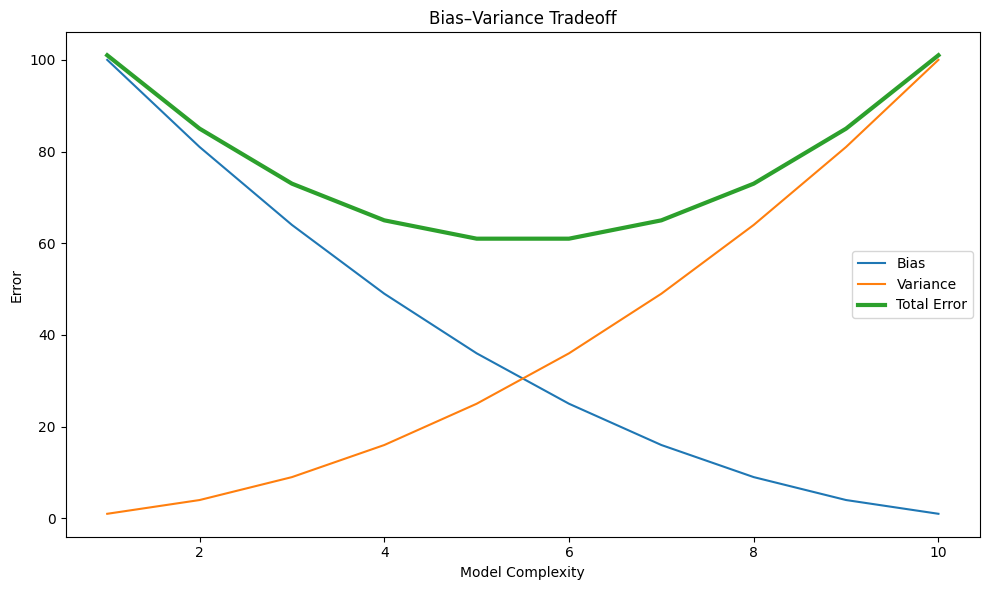

In [16]:
import numpy as np
import matplotlib.pyplot as plt

model_complexity = np.linspace(1,10,10)
bias = (11 - model_complexity)**2
variance = model_complexity**2
total_error = bias + variance

plt.figure(figsize=(10,6))
plt.plot(model_complexity, bias, label="Bias")
plt.plot(model_complexity, variance, label="Variance")
plt.plot(model_complexity, total_error, label="Total Error", linewidth=3)
plt.legend()
plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.title("Bias–Variance Tradeoff")
plt.tight_layout()
plt.show()


• Simple models → high bias (they miss patterns)  
• Complex models → high variance (they memorize noise)  
• Good models → find the happy middle  


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_s = scaler.fit_transform(X)

lin_raw = LinearRegression().fit(X, y)
lin_s   = LinearRegression().fit(X_s, y)

pd.DataFrame({
    "Raw Coef": lin_raw.coef_,
    "Scaled Coef": lin_s.coef_
}, index=features)


,Raw Coef,Scaled Coef
bill_total_usd,0.090313,2.384720
party_size,0.104463,0.134850
gender_Male,-0.206386,-0.102940
is_smoker_Yes,-0.693590,-0.318594


• Regularization punishes "large numbers"  
• If predictors are on different scales, the model unfairly penalizes big units  
• Standardizing puts all features on equal footing  


In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {"alpha": np.logspace(-3,3,20)}

ridge_cv = GridSearchCV(Ridge(), param_grid, cv=5)
ridge_cv.fit(X_train_s, y_train)

lasso_cv = GridSearchCV(Lasso(), param_grid, cv=5)
lasso_cv.fit(X_train_s, y_train)

ridge_cv.best_params_, lasso_cv.best_params_


({'alpha': np.float64(2.976351441631316)},
 {'alpha': np.float64(0.07847599703514611)})

Grid search tests many values of alpha and keeps the one  
that makes the model best on unseen data.


In [20]:
import numpy as np

coef_records = {feat: [] for feat in features}

for seed in range(50):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    X_train_s = scaler.fit_transform(X_train)
    model = Ridge(alpha=1.0).fit(X_train_s, y_train)
    
    for i, feat in enumerate(features):
        coef_records[feat].append(model.coef_[i])

pd.DataFrame(coef_records).describe()


,bill_total_usd,party_size,gender_Male,is_smoker_Yes
count,50.000000,50.000000,50.000000,50.000000
mean,2.371521,0.124080,-0.094334,-0.306859
std,0.075155,0.058983,0.061471,0.060074
min,2.202446,-0.021752,-0.215435,-0.441621
25%,2.327814,0.089781,-0.128866,-0.353694
50%,2.381036,0.119685,-0.101086,-0.309724
75%,2.416904,0.161356,-0.057786,-0.272706
max,2.538346,0.282510,0.058519,-0.165039


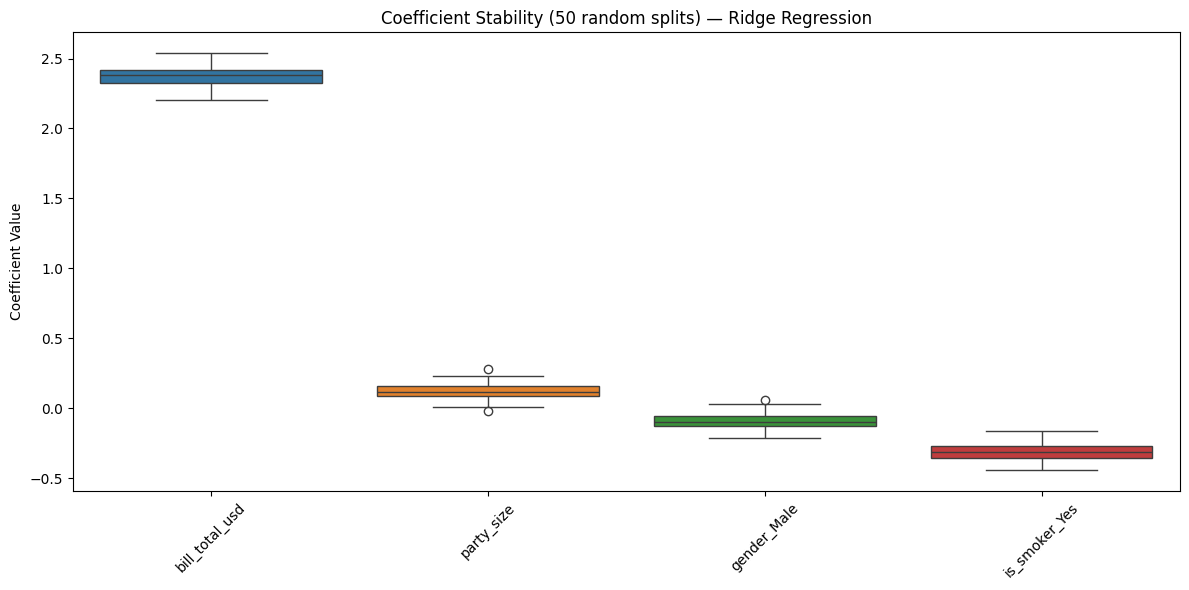

In [22]:
coef_records = {feat: [] for feat in features}

scaler = StandardScaler()

for seed in range(50):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    X_train_s = scaler.fit_transform(X_train)

    model = Ridge(alpha=1.0).fit(X_train_s, y_train)

    for i, feat in enumerate(features):
        coef_records[feat].append(model.coef_[i])

coef_stability = pd.DataFrame(coef_records)

plt.figure(figsize=(12,6))
sns.boxplot(data=coef_stability)
plt.title("Coefficient Stability (50 random splits) — Ridge Regression")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Stable models → coefficients don’t bounce around much  
Unstable models → coefficients change wildly with new data  
Regularization stabilizes them.


### Coefficient Shrinkage Across Models

**What this chart shows (ELI5):**

- We have **four models** looking at the same data:  
  - Ordinary **Linear Regression**  
  - **Ridge** (L2)  
  - **Lasso** (L1)  
  - **ElasticNet** (mix of L1 + L2)  

- Each bar is a **feature’s coefficient** (how much that feature pushes the tip up or down).

- **Linear Regression** often has the **largest, most wiggly** coefficients (can overfit).
- **Ridge** shrinks all coefficients **toward zero**, but usually keeps them non-zero.
- **Lasso** can shrink some coefficients **all the way to zero** → it can *drop* features.
- **ElasticNet** is a compromise: some shrinkage like Ridge, some feature dropping like Lasso.

**Big idea:**  
Regularization is like putting rubber bands on the coefficients so they don’t grow wild.  
Smaller, more controlled bars = **simpler, more stable model** (less overfitting risk).


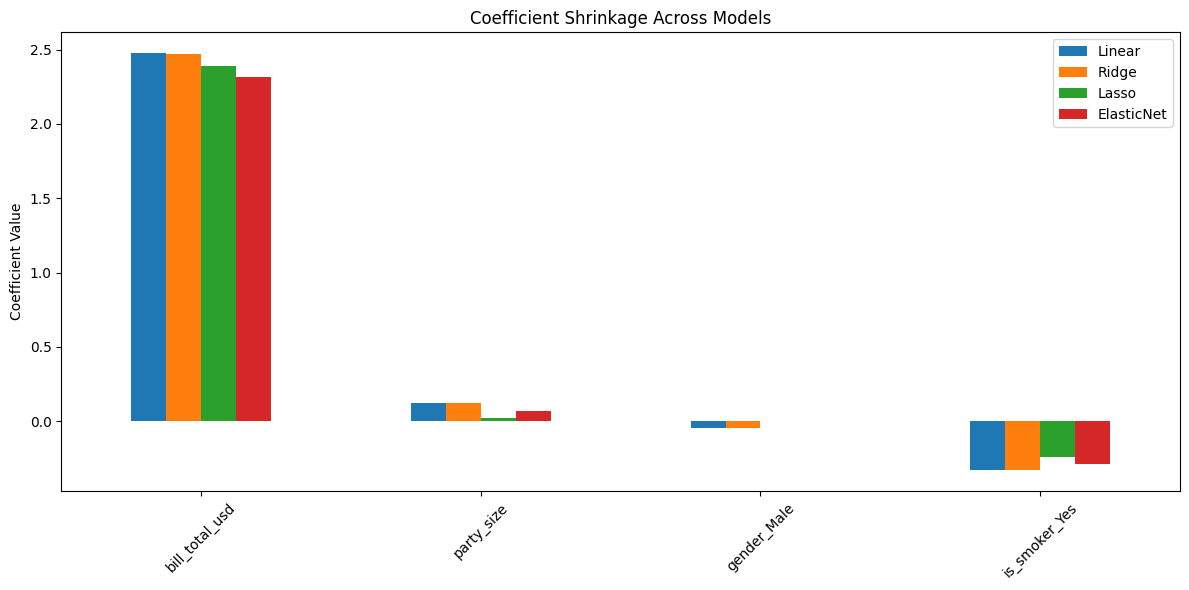

✅ Saved Matplotlib figure to: reports/figures/coefficient_shrinkage_across_models_2025-11-25_1957.png
📝 Logged metadata → reports/figures/coefficient_shrinkage_across_models_2025-11-25_1957.json


(PosixPath('reports/figures/coefficient_shrinkage_across_models_2025-11-25_1957.png'),
 PosixPath('reports/figures/coefficient_shrinkage_across_models_2025-11-25_1957.json'))

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from src.helpers import save_and_log_plot

# 1) Load data
df = pd.read_csv("data/processed/tips_synthetic.csv")

# 2) Encode categoricals safely
df_work = df.copy()

if "gender" in df_work.columns and "gender_Male" not in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["gender"], prefix="gender", drop_first=True)

if "is_smoker" in df_work.columns and "is_smoker_Yes" not in df_work.columns:
    df_work = pd.get_dummies(df_work, columns=["is_smoker"], prefix="is_smoker", drop_first=True)

features = ["bill_total_usd", "party_size", "gender_Male", "is_smoker_Yes"]
X = df_work[features]
y = df_work["tip_usd"]

# 3) Train/test split + scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

# 4) Define models
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
}

coef_df = pd.DataFrame(index=features)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    coef_df[name] = model.coef_

# 5) Plot
fig, ax = plt.subplots(figsize=(12, 6))
coef_df.plot(kind="bar", ax=ax)
ax.set_title("Coefficient Shrinkage Across Models")
ax.set_ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6) Save with metadata + timestamped PNG + JSON
save_and_log_plot(
    fig,
    "reports/figures/coefficient_shrinkage_across_models.png",
    df=df_work,
    chart_type="bar",
    library="matplotlib",
    x="feature",
    y="coefficient",
    dataset_name="tips_synthetic",
    dataset_path="data/processed/tips_synthetic.csv",
    notebook="notebooks/07C_RegularizationOverfittingandModelStability.ipynb",
    notes="Coefficient shrinkage across Linear, Ridge, Lasso, ElasticNet.",
    timestamped=True,
)


### Ridge Coefficient Paths (α vs Coefficients)

**What this chart shows (ELI5):**

- We take **Ridge Regression** and slowly turn up the **regularization knob α**.
- On the x-axis: different values of α (log scale).
- On the y-axis: each line is a **feature’s coefficient**.

As **α is small** (left side):

- Coefficients can be large and wiggly (more like plain Linear Regression).

As **α grows** (move right):

- All lines get pulled **toward zero** → coefficients shrink.
- Features that were noisy or weak get pulled closer to zero fastest.

**Big idea:**  
Ridge is like tightening a belt around all coefficients.  
Higher α = tighter belt = smaller, more conservative coefficients.


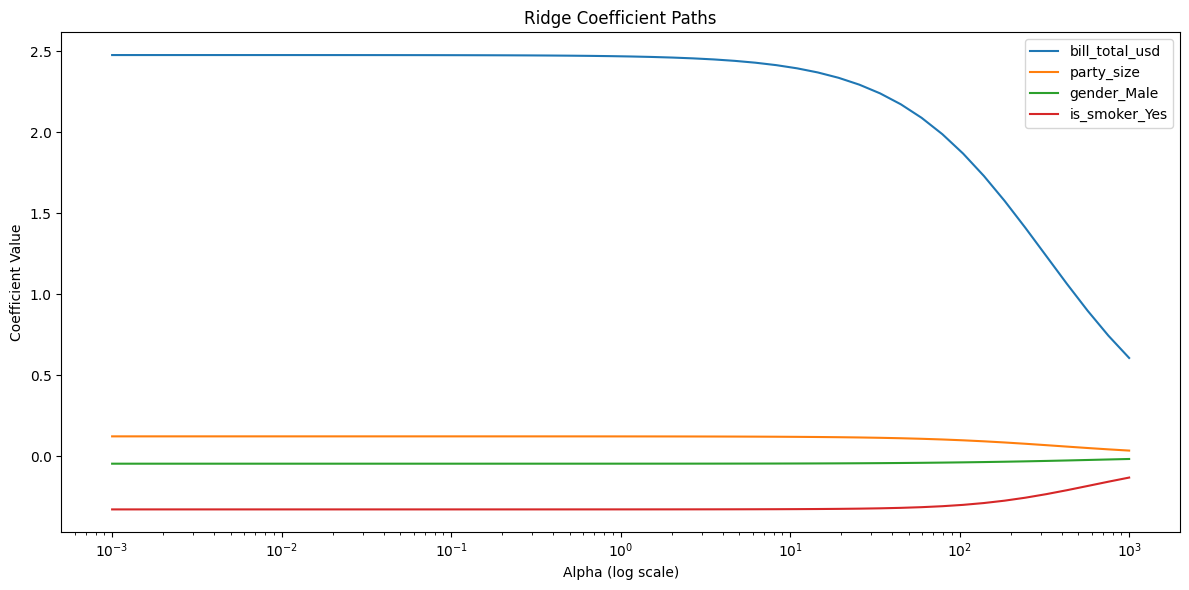

✅ Saved Matplotlib figure to: reports/figures/ridge_coefficient_paths_2025-11-25_1958.png
📝 Logged metadata → reports/figures/ridge_coefficient_paths_2025-11-25_1958.json


(PosixPath('reports/figures/ridge_coefficient_paths_2025-11-25_1958.png'),
 PosixPath('reports/figures/ridge_coefficient_paths_2025-11-25_1958.json'))

In [24]:
from sklearn.linear_model import Ridge

alphas = np.logspace(-3, 3, 50)
coef_paths = []

for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_train_s, y_train)
    coef_paths.append(r.coef_)

coef_paths = np.array(coef_paths)

fig, ax = plt.subplots(figsize=(12, 6))
for i, feat in enumerate(features):
    ax.plot(alphas, coef_paths[:, i], label=feat)

ax.set_xscale("log")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Coefficient Value")
ax.set_title("Ridge Coefficient Paths")
ax.legend()
plt.tight_layout()
plt.show()

save_and_log_plot(
    fig,
    "reports/figures/ridge_coefficient_paths.png",
    df=df_work,
    chart_type="line",
    library="matplotlib",
    x="alpha",
    y="coefficient",
    dataset_name="tips_synthetic",
    dataset_path="data/processed/tips_synthetic.csv",
    notebook="notebooks/07C_RegularizationOverfittingandModelStability.ipynb",
    notes="Ridge coefficient paths: how coefficients shrink as alpha increases.",
    timestamped=True,
)


### Bias–Variance Tradeoff (Conceptual Curve)

**What this chart shows (ELI5):**

- Imagine a **slider for model complexity**:
  - Left = very simple model  
  - Right = very complex model  

We track three things:

- **Bias** (blue): error from being *too simple*  
  - Simple models miss patterns → high bias at the left, lower at the right.
- **Variance** (orange): error from being *too wiggly*  
  - Complex models overreact to noise → low on the left, high on the right.
- **Total Error** (green): bias + variance  
  - Makes a **U-shaped curve** → there’s a “sweet spot” in the middle.

**Big idea:**  
Too simple = wrong in the same way all the time (high bias).  
Too complex = overfits each sample (high variance).  
We want the **sweet spot** where total error is lowest.


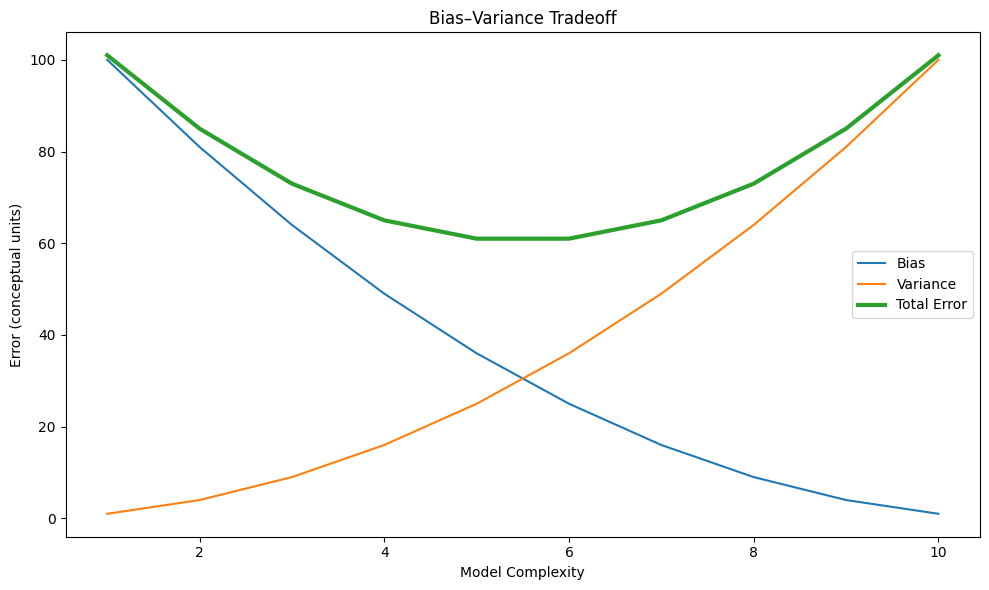

✅ Saved Matplotlib figure to: reports/figures/bias_variance_tradeoff_2025-11-25_2000.png
📝 Logged metadata → reports/figures/bias_variance_tradeoff_2025-11-25_2000.json


(PosixPath('reports/figures/bias_variance_tradeoff_2025-11-25_2000.png'),
 PosixPath('reports/figures/bias_variance_tradeoff_2025-11-25_2000.json'))

In [25]:
# Synthetic / conceptual example — not tied to the actual data
model_complexity = np.linspace(1, 10, 10)

bias = (11 - model_complexity) ** 2
variance = model_complexity ** 2
total_error = bias + variance

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(model_complexity, bias, label="Bias")
ax.plot(model_complexity, variance, label="Variance")
ax.plot(model_complexity, total_error, label="Total Error", linewidth=3)

ax.set_xlabel("Model Complexity")
ax.set_ylabel("Error (conceptual units)")
ax.set_title("Bias–Variance Tradeoff")
ax.legend()
plt.tight_layout()
plt.show()

save_and_log_plot(
    fig,
    "reports/figures/bias_variance_tradeoff.png",
    df=None,
    chart_type="line",
    library="matplotlib",
    x="model_complexity",
    y="error_components",
    dataset_name="synthetic_bias_variance_demo",
    dataset_path=None,
    notebook="notebooks/07C_RegularizationOverfittingandModelStability.ipynb",
    notes="Conceptual bias–variance tradeoff curve.",
    timestamped=True,
)


### Coefficient Stability Across 50 Random Train/Test Splits (Ridge)

**What this chart shows (ELI5):**

- We run the **same Ridge model 50 times**, each time with a different random train/test split.
- For each feature, we collect the 50 fitted coefficients and draw a **boxplot**.

How to read the boxplots:

- **Narrow, short boxes** → the coefficient stays almost the same across splits  
  → the feature is **stable and reliable**.
- **Tall, wide boxes** → the coefficient jumps around a lot  
  → the feature is **sensitive to the particular sample** (less stable).

**Big idea:**  
A good model doesn’t wildly change its story about a feature every time you reshuffle the data.  
Stable coefficients = more trustworthy interpretation.


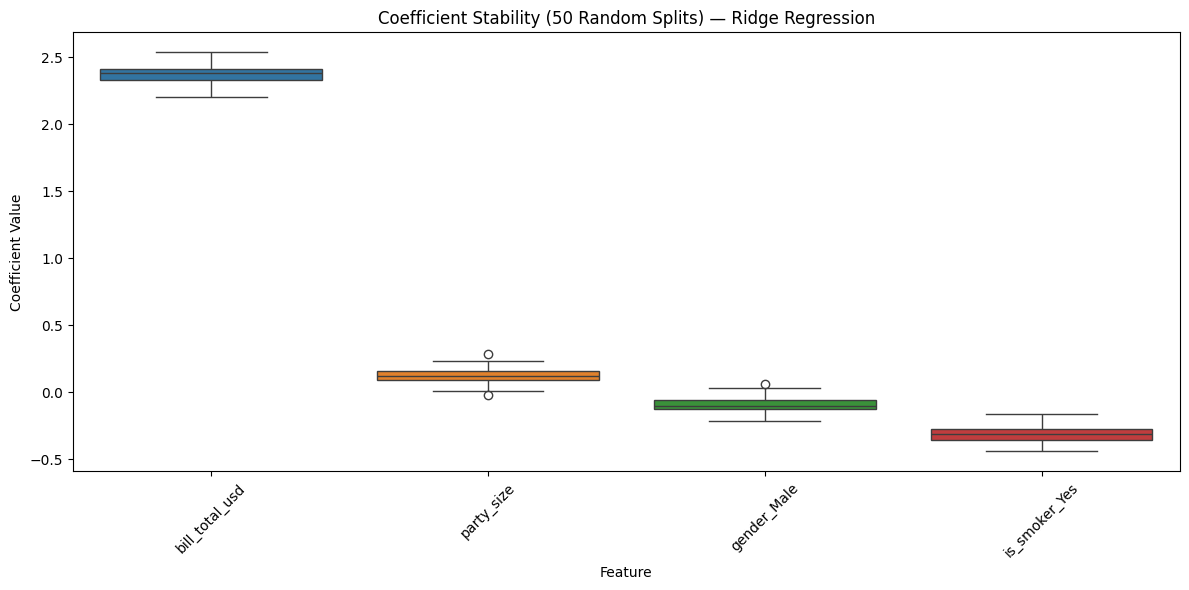

✅ Saved Matplotlib figure to: reports/figures/ridge_coefficient_stability_50splits_2025-11-25_2000.png
📝 Logged metadata → reports/figures/ridge_coefficient_stability_50splits_2025-11-25_2000.json


(PosixPath('reports/figures/ridge_coefficient_stability_50splits_2025-11-25_2000.png'),
 PosixPath('reports/figures/ridge_coefficient_stability_50splits_2025-11-25_2000.json'))

In [26]:
from sklearn.linear_model import Ridge

coef_records = {feat: [] for feat in features}
scaler = StandardScaler()

for seed in range(50):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    X_train_s = scaler.fit_transform(X_train)
    model = Ridge(alpha=1.0).fit(X_train_s, y_train)

    for i, feat in enumerate(features):
        coef_records[feat].append(model.coef_[i])

coef_stability = pd.DataFrame(coef_records)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=coef_stability, ax=ax)
ax.set_title("Coefficient Stability (50 Random Splits) — Ridge Regression")
ax.set_ylabel("Coefficient Value")
ax.set_xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

save_and_log_plot(
    fig,
    "reports/figures/ridge_coefficient_stability_50splits.png",
    df=df_work,
    chart_type="boxplot",
    library="seaborn",
    x="feature",
    y="coefficient",
    dataset_name="tips_synthetic",
    dataset_path="data/processed/tips_synthetic.csv",
    notebook="notebooks/07C_RegularizationOverfittingandModelStability.ipynb",
    notes="Coefficient stability across 50 random train/test splits using Ridge.",
    timestamped=True,
)
